# VAE

In [ ]:
import os, math, json, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from dataclasses import dataclass, asdict
import pandas as pd

def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print("TF:", tf.__version__)


2025-11-04 10:30:03.555603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762252203.726376      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762252203.771151      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF: 2.18.0


This cell loads and preprocesses the Fashion-MNIST data for a TensorFlow model. It ensures all images have the channels-last shape (N, 28, 28, 1), converting from other formats if needed. Shape checks guarantee data consistency, preventing training errors. It then builds efficient tf.data.Dataset pipelines with shuffling, batching, and prefetching for optimal GPU utilization. The datasets return only images, matching autoencoder/VAE training needs. This setup improves reproducibility, performance, and data reliability.

In [ ]:
from pathlib import Path
import numpy as np
import tensorflow as tf

def _to_channels_last_np(arr):
    if arr.ndim == 4:
        N, a, b, c = arr.shape[0], arr.shape[1], arr.shape[2], arr.shape[3]
        # NCHW case?
        if a == 1 and b == 28 and c == 28:
            arr = np.transpose(arr, (0, 2, 3, 1))  # (N, 1, 28, 28) -> (N, 28, 28, 1)
        elif (a, b, c) != (28, 28, 1):
            raise ValueError(f"Unexpected 4D shape: {arr.shape}. Expected (N,28,28,1) or (N,1,28,28).")
        return arr
    elif arr.ndim == 3:
        N, a, b = arr.shape
        if (a, b) != (28, 28):
            raise ValueError(f"Unexpected 3D shape: {arr.shape}. Expected (N,28,28).")
        return arr[..., np.newaxis]  # (N,28,28) -> (N,28,28,1)
    else:
        raise ValueError(f"Unexpected shape: {arr.shape}. Expected 3D or 4D.")

def get_datasets(batch_size=128, seed=42, shuffle_buffer=8192):
    DATASETS_DIR = Path("/kaggle/input/d/YOUR_KAGGLE_USERNAME/resulteda/output_bundle/datasets")

    # Load splits
    train = np.load(DATASETS_DIR / "fashion_mnist_vae_train.npz")
    val   = np.load(DATASETS_DIR / "fashion_mnist_vae_val.npz")
    test  = np.load(DATASETS_DIR / "fashion_mnist_vae_test.npz")

    X_train, y_train = train["X"].astype("float32"), train["y"]
    X_val,   y_val   = val["X"].astype("float32"),   val["y"]
    X_test,  y_test  = test["X"].astype("float32"),  test["y"]

    # Normalize to channels_last with NumPy 
    X_train = _to_channels_last_np(X_train)
    X_val   = _to_channels_last_np(X_val)
    X_test  = _to_channels_last_np(X_test)

    # Sanity checks
    assert X_train.shape[1:] == (28, 28, 1), f"Wrong train shape: {X_train.shape}"
    assert X_val.shape[1:]   == (28, 28, 1), f"Wrong val shape: {X_val.shape}"
    assert X_test.shape[1:]  == (28, 28, 1), f"Wrong test shape: {X_test.shape}"

    # Build datasets with images only 
    AUTOTUNE = tf.data.AUTOTUNE
    ds_train = (tf.data.Dataset.from_tensor_slices(X_train)
                .shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
                .batch(batch_size)
                .prefetch(AUTOTUNE))
    ds_val   = tf.data.Dataset.from_tensor_slices(X_val).batch(batch_size).prefetch(AUTOTUNE)
    ds_test  = tf.data.Dataset.from_tensor_slices(X_test).batch(batch_size).prefetch(AUTOTUNE)

    return ds_train, ds_val, ds_test, (X_train, X_val, X_test)


Now:
* **Builds a Variational Autoencoder (VAE)** for 28×28 grayscale images (e.g., Fashion-MNIST): an **encoder** compresses an image to a small latent vector, and a **decoder** reconstructs it back.
* Adds a **Sampling** layer that injects gentle randomness, so the model learns a smooth latent space instead of memorizing images.
* Offers two styles of building blocks—**residual** or **plain conv**—plus optional **dropout**, **layer normalization**, and light **data augmentation** to improve stability and generalization.
* Lets you choose **how to upsample** in the decoder (transpose-conv or upsample+conv) to balance sharpness and artifact control.
* Keeps **backward compatibility**: defaults mirror a simple VAE, while flags (`use_residual`, `deepen`, `use_upsample`, etc.) let you scale depth/quality without rewriting code.
* The custom `VAE` class handles training: it tracks **reconstruction quality** and the **KL penalty** that keeps the latent space compact and meaningful.
* You can train with standard probabilities or **logits** (toggle with `use_logits_loss`) depending on your preferred decoder output.
* A **BetaScheduler callback** gradually increases the KL weight (“**warm-up**”), making training gentler at the start and often yielding better, more coherent latents.
* Net effect: a flexible, production-friendly VAE you can start simple, then **dial up capacity and regularization** as results or compute budgets allow.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------
# Sampling 
# ---------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

# ---------------------------
# Helper 
# ---------------------------
def conv_block(x, filters, stride=1, use_ln=True, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=not use_ln,
                      kernel_initializer="he_normal")(x)
    if use_ln:
        x = layers.LayerNormalization(axis=[1,2,3])(x)
    x = layers.LeakyReLU(0.2)(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    return x

def residual_block_down(x, filters, stride=1, use_ln=True, dropout_rate=0.0):

    y = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=not use_ln,
                      kernel_initializer="he_normal")(x)
    if use_ln: y = layers.LayerNormalization(axis=[1,2,3])(y)
    y = layers.LeakyReLU(0.2)(y)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=not use_ln,
                      kernel_initializer="he_normal")(y)
    if use_ln: y = layers.LayerNormalization(axis=[1,2,3])(y)
    # skip
    if stride != 1 or x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, strides=stride, padding="same",
                          kernel_initializer="he_normal")(x)
    out = layers.LeakyReLU(0.2)(x + y)
    if dropout_rate > 0.0:
        out = layers.Dropout(dropout_rate)(out)
    return out

def upsample_block(x, filters, use_ln=True, dropout_rate=0.0, use_upsample=False):
    if use_upsample:
        # UpSampling2D + Conv2D 
        x = layers.UpSampling2D()(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=not use_ln,
                          kernel_initializer="he_normal")(x)
    else:
        # Conv2DTranspose
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same",
                                   kernel_initializer="he_normal")(x)
    if use_ln:
        x = layers.LayerNormalization(axis=[1,2,3])(x)
    x = layers.LeakyReLU(0.2)(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    return x

def residual_block_up(x, filters, use_ln=True, dropout_rate=0.0, use_upsample=False):
    # main
    y = upsample_block(x, filters, use_ln=use_ln, dropout_rate=0.0, use_upsample=use_upsample)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=not use_ln,
                      kernel_initializer="he_normal")(y)
    if use_ln: y = layers.LayerNormalization(axis=[1,2,3])(y)
    skip = x
    if use_upsample:
        skip = layers.UpSampling2D()(skip)
        skip = layers.Conv2D(filters, 1, padding="same", kernel_initializer="he_normal")(skip)
    else:
        skip = layers.Conv2DTranspose(filters, 1, strides=2, padding="same",
                                      kernel_initializer="he_normal")(skip)
    out = layers.LeakyReLU(0.2)(skip + y)
    if dropout_rate > 0.0:
        out = layers.Dropout(dropout_rate)(out)
    return out

# ---------------------------
# Encoder/Decoder 
# ---------------------------
def build_encoder(
    z_dim=32,
    use_residual=True,           
    deepen=1,                   
    use_ln=True,
    dropout_rate=0.0,
    augment=False                
):
    inp = layers.Input(shape=(28,28,1))
    x = inp
    if augment:
        x = layers.RandomTranslation(0.05, 0.05)(x)
        x = layers.RandomRotation(0.05)(x)

    if use_residual:
        x = residual_block_down(x, 32, stride=2, use_ln=use_ln, dropout_rate=dropout_rate)
        x = residual_block_down(x, 64, stride=2, use_ln=use_ln, dropout_rate=dropout_rate)
        for _ in range(deepen):
            x = residual_block_down(x, 64, stride=1, use_ln=use_ln, dropout_rate=dropout_rate)
    else:
        x = conv_block(x, 32, stride=2, use_ln=use_ln, dropout_rate=dropout_rate)
        x = conv_block(x, 64, stride=2, use_ln=use_ln, dropout_rate=dropout_rate)
        for _ in range(deepen):
            x = conv_block(x, 64, stride=1, use_ln=use_ln, dropout_rate=dropout_rate)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    z_mean = layers.Dense(z_dim, name="z_mean")(x)
    z_log_var = layers.Dense(z_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(inp, [z_mean, z_log_var, z], name="encoder")

def build_decoder(
    z_dim=32,
    use_residual=True,           
    deepen=1,                    
    use_ln=True,
    dropout_rate=0.0,
    use_upsample=False,          
    final_activation="sigmoid"   
):
    inp = layers.Input(shape=(z_dim,))
    x = layers.Dense(7*7*64, activation="relu")(inp)
    x = layers.Reshape((7,7,64))(x)

    if use_residual:
        x = residual_block_up(x, 64, use_ln=use_ln, dropout_rate=dropout_rate, use_upsample=use_upsample)
        x = residual_block_up(x, 32, use_ln=use_ln, dropout_rate=dropout_rate, use_upsample=use_upsample)
        for _ in range(deepen):
            y = layers.Conv2D(32, 3, padding="same", use_bias=not use_ln,
                              kernel_initializer="he_normal")(x)
            if use_ln: y = layers.LayerNormalization(axis=[1,2,3])(y)
            y = layers.LeakyReLU(0.2)(y)
            y = layers.Conv2D(32, 3, padding="same", use_bias=not use_ln,
                              kernel_initializer="he_normal")(y)
            if use_ln: y = layers.LayerNormalization(axis=[1,2,3])(y)
            x = layers.LeakyReLU(0.2)(x + y)
            if dropout_rate > 0.0:
                x = layers.Dropout(dropout_rate)(x)
    else:
        x = upsample_block(x, 64, use_ln=use_ln, dropout_rate=dropout_rate, use_upsample=use_upsample)
        x = upsample_block(x, 32, use_ln=use_ln, dropout_rate=dropout_rate, use_upsample=use_upsample)
        for _ in range(deepen):
            x = conv_block(x, 32, stride=1, use_ln=use_ln, dropout_rate=dropout_rate)

    out = layers.Conv2D(1, 3, padding="same", activation=final_activation)(x)
    return keras.Model(inp, out, name="decoder")

# ---------------------------
# VAE 
# ---------------------------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, use_logits_loss=False):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = tf.Variable(beta, trainable=False, dtype=tf.float32, name="beta")
        self.use_logits_loss = use_logits_loss  

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _recon_loss(self, x, x_rec):
        if self.use_logits_loss:
            
            bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=x, logits=x_rec)
        else:
            bce = keras.losses.binary_crossentropy(x, x_rec)
        
        if bce.shape.rank == 4:
            return tf.reduce_mean(tf.reduce_sum(bce, axis=(1,2,3)))
        else:
            return tf.reduce_mean(tf.reduce_sum(bce, axis=(1,2)))

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            x_rec = self.decoder(z, training=True)
            recon = self._recon_loss(x, x_rec)
            kl = -0.5 * tf.reduce_mean(tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            loss = recon + self.beta * kl
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(loss)
        self.recon_loss_tracker.update_state(recon)
        self.kl_loss_tracker.update_state(kl)
        return {"loss": self.total_loss_tracker.result(),
                "recon": self.recon_loss_tracker.result(),
                "kl": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        x_rec = self.decoder(z, training=False)
        recon = self._recon_loss(x, x_rec)
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        loss = recon + self.beta * kl
        return {"val_loss": loss, "val_recon": recon, "val_kl": kl}

# ---------------------------
# Callback for KL warm-up 
# ---------------------------
class BetaScheduler(keras.callbacks.Callback):
    def __init__(self, beta_final=1.0, warmup_epochs=10):
        super().__init__()
        self.beta_final = beta_final
        self.warmup_epochs = warmup_epochs
    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epochs > 0:
            t = min(1.0, epoch / float(self.warmup_epochs))
            self.model.beta.assign(self.beta_final * t)
        else:
            self.model.beta.assign(self.beta_final)


This cell adds two training callbacks for controlling and tracking **β** in a VAE.
**BetaAnnealCallback** supports two modes: **fixed** (β stays at the target) and **anneal** (β ramps linearly from 0 to the target over `warmup_epochs`).
Starting from β=0 prioritizes reconstruction early, then gradually adds regularization (KL) as training stabilizes.
It updates the model’s `vae.beta` at the start and at each epoch (for annealing).
**BetaLogger** simply logs the current β into Keras `logs`, so you can see it in the training history.
Together, they make β scheduling explicit, reproducible, and easy to monitor.


In [4]:
class BetaAnnealCallback(tf.keras.callbacks.Callback):
    """
    Supported modes:
    - fixed  : beta remains constant = target
    - anneal : beta increases linearly 0 -> target over 'warmup_epochs', then stays at target
    """
    def __init__(self, vae, mode="fixed", target=1.0, warmup_epochs=5):
        super().__init__()
        self.vae = vae
        self.mode = str(mode)
        self.target = float(target)
        self.warmup = int(max(1, warmup_epochs))

    def on_train_begin(self, logs=None):
        if self.mode == "fixed":
            self.vae.beta.assign(self.target)
        elif self.mode == "anneal":
            # start from 0 for unregularized reconstruction at the beginning
            self.vae.beta.assign(0.0)
        else:
            # fallback: fixed
            self.vae.beta.assign(self.target)

    def on_epoch_begin(self, epoch, logs=None):
        if self.mode != "anneal":
            return
        t = min(1.0, (epoch + 1) / self.warmup)  # 1-indexed progress
        self.vae.beta.assign(t * self.target)

class BetaLogger(tf.keras.callbacks.Callback):
    """Adds the current beta to logs so it appears in the History object."""
    def __init__(self, vae):
        super().__init__()
        self.vae = vae
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["beta"] = float(self.vae.beta.numpy())


Now:
* Defines a **RunConfig** dataclass to centralize hyperparameters (latent size, LR, β schedule, batch size, epochs, seed).
* `train_one_run` sets seeds, builds **datasets**, then constructs **encoder/decoder** and a **VAE** with initial β (0 if annealing, else fixed).
* Compiles with **Adam** and attaches **BetaAnnealCallback** (controls β over epochs) and **BetaLogger** (records β in history).
* Trains with validation and returns the **History**’s final validation metrics.
* Reports `val_val_loss`, `val_val_recon`, `val_val_kl` (if present), and the **final β**.
* Merges metrics with the full **config** via `asdict(cfg)` for easy tracking/comparison.
* Also returns the trained **vae** model for evaluation or sampling.


In [ ]:
from dataclasses import dataclass, asdict
import numpy as np
import tensorflow as tf

@dataclass
class RunConfig:
    z_dim: int = 32
    lr: float = 1e-3
    beta: float = 1.0          
    beta_mode: str = "fixed"    
    beta_target: float = 1.0   
    beta_warmup: int = 5       
    batch_size: int = 128
    epochs: int = 10
    seed: int = 42

def train_one_run(cfg: RunConfig):
    set_seeds(cfg.seed)

    ds_train, ds_val = get_datasets(batch_size=cfg.batch_size)[:2]

    encoder = build_encoder(cfg.z_dim)
    decoder = build_decoder(cfg.z_dim)

    # initial beta: if anneal, start from 0; if fixed, start from cfg.beta
    init_beta = 0.0 if cfg.beta_mode == "anneal" else cfg.beta
    vae = VAE(encoder, decoder, beta=init_beta)

    opt = tf.keras.optimizers.Adam(learning_rate=cfg.lr)
    vae.compile(optimizer=opt)

    callbacks = [
        BetaAnnealCallback(
            vae,
            mode=cfg.beta_mode,
            target=cfg.beta_target if hasattr(cfg, "beta_target") else cfg.beta,
            warmup_epochs=cfg.beta_warmup if hasattr(cfg, "beta_warmup") else 5
        ),
        BetaLogger(vae),
    ]

    hist = vae.fit(
        ds_train,
        validation_data=ds_val,
        epochs=cfg.epochs,
        verbose=1,
        callbacks=callbacks
    )

    results = {
        "val_val_loss": float(hist.history["val_val_loss"][-1]),
        "val_val_recon": float(hist.history.get("val_val_recon", [np.nan])[-1]),
        "val_val_kl": float(hist.history.get("val_val_kl", [np.nan])[-1]),
        "final_beta": float(vae.beta.numpy()),
        **asdict(cfg),
    }
    return results, vae


This sweep probes complementary regimes to balance reconstruction fidelity, disentanglement, and training stability. The baseline (z=32, β fixed=1.0, lr=1e-3) serves as a strong reference. The z=64 + anneal variant tests whether increased latent capacity benefits representation when β ramps slowly (warm-up=40), mitigating early KL collapse. The z=32 + anneal @ lower lr isolates optimization effects, asking whether a gentler step size stabilizes the β warm-up. New #1 (z=32, lr=1e-3, β: 0.5→2.0 over 20 epochs) stresses KL regularization earlier and harder to examine disentanglement under stronger pressure. New #2 (fixed β=1.0, slightly lower lr, mild ↑dropout/↑patience) is a conservative control to assess robustness gains from modest regularization without changing the objective. Shared settings (batch size, epochs, weight decay, early stopping) standardize comparison and reduce confounds.

In [ ]:
sweep_list = [
    # --- Previous BEST: kept unchanged ---
    {
        "model": "vae",
        "seed": 42,
        "batch": 128,
        "val_split": 0.1,
        "shuffle": 50000,
        "z_dim": 32,
        "lr": 1e-3,
        "epochs": 75,
        "dropout": 0.10,
        "weight_decay": 1.0e-4,
        "early_patience": 10,
        "beta_mode": "fixed",
        "beta_init": 1.0,
        "beta_target": 2.0, #ignored if it is fixed
        "beta_warmup": 0,
        "sample_period": 5,
        "n_prior": 16,
    },

    # --- Keep: solid variant with z_dim=64 / anneal ---
    {
        "model": "vae",
        "seed": 42,
        "batch": 128,
        "val_split": 0.1,
        "shuffle": 50000,
        "z_dim": 64,
        "lr": 5e-4,
        "epochs": 75,
        "dropout": 0.10,
        "weight_decay": 1.0e-4,
        "early_patience": 12,
        "beta_mode": "anneal",
        "beta_init": 0.0,
        "beta_target": 1.0,
        "beta_warmup": 40,
        "sample_period": 5,
        "n_prior": 16,
    },

    # --- Keep: z_dim=32 / anneal with lower lr ---
    {
        "model": "vae",
        "seed": 42,
        "batch": 128,
        "val_split": 0.1,
        "shuffle": 50000,
        "z_dim": 32,
        "lr": 5e-4,
        "epochs": 75,
        "dropout": 0.15,
        "weight_decay": 1.0e-4,
        "early_patience": 10,
        "beta_mode": "anneal",
        "beta_init": 0.0,
        "beta_target": 1.0,
        "beta_warmup": 10,
        "sample_period": 5,
        "n_prior": 16,
    },

    # === optimization with more aggressive anneal ===
    {
        "model": "vae",
        "seed": 42,
        "batch": 128,
        "val_split": 0.1,
        "shuffle": 50000,
        "z_dim": 32,          # keep 32 (performed best)
        "lr": 1e-3,           # same as 1st best
        "epochs": 75,
        "dropout": 0.10,
        "weight_decay": 1.0e-4,
        "early_patience": 10,
        "beta_mode": "anneal",
        "beta_init": 0.5,     # start not too low
        "beta_target": 2.0,   # pushes KL a bit more
        "beta_warmup": 20,    # faster annealing than standard
        "sample_period": 5,
        "n_prior": 16,
    },

    # === mild regularization ===
    {
        "model": "vae",
        "seed": 42,
        "batch": 128,
        "val_split": 0.1,
        "shuffle": 50000,
        "z_dim": 32,
        "lr": 8e-4,           # slightly lower for stability
        "epochs": 75,         # a bit longer with early stopping
        "dropout": 0.12,      # mild increase in regularization
        "weight_decay": 1.0e-4,
        "early_patience": 12,
        "beta_mode": "fixed",
        "beta_init": 1.0,     # same beta as best
        "beta_target": 2.0,   # ignored in "fixed"
        "beta_warmup": 0,
        "sample_period": 5,
        "n_prior": 16,
    },
]


from dataclasses import asdict

def to_cfg(d):
    # Inject defaults where fields are missing
    return RunConfig(
        z_dim=d.get("z_dim", 32),
        lr=d.get("lr", 1e-3),
        beta=d.get("beta", 1.0),
        beta_mode=d.get("beta_mode", "fixed"),
        beta_target=d.get("beta_target", 1.0),
        beta_warmup=d.get("beta_warmup", 5),
        batch_size=d.get("batch_size", 128),
        epochs=d.get("epochs", 10),
        seed=d.get("seed", 42),
    )

len(sweep_list), sweep_list[:2]


(5,
 [{'model': 'vae',
   'seed': 42,
   'batch': 128,
   'val_split': 0.1,
   'shuffle': 50000,
   'z_dim': 32,
   'lr': 0.001,
   'epochs': 75,
   'dropout': 0.1,
   'weight_decay': 0.0001,
   'early_patience': 10,
   'beta_mode': 'fixed',
   'beta_init': 1.0,
   'beta_target': 2.0,
   'beta_warmup': 0,
   'sample_period': 5,
   'n_prior': 16},
  {'model': 'vae',
   'seed': 42,
   'batch': 128,
   'val_split': 0.1,
   'shuffle': 50000,
   'z_dim': 64,
   'lr': 0.0005,
   'epochs': 75,
   'dropout': 0.1,
   'weight_decay': 0.0001,
   'early_patience': 12,
   'beta_mode': 'anneal',
   'beta_init': 0.0,
   'beta_target': 1.0,
   'beta_warmup': 40,
   'sample_period': 5,
   'n_prior': 16}])

# Training & Grid Search

In [7]:
all_results = []
trained_models = []  

for i, d in enumerate(sweep_list, 1):
    cfg = to_cfg(d)
    print("\n" + "="*80)
    print(f"[{i}/{len(sweep_list)}] Start run: z_dim={cfg.z_dim} lr={cfg.lr} beta_mode={cfg.beta_mode}")
    print("="*80)
    res, model = train_one_run(cfg)
    all_results.append(res)
    trained_models.append(model)

print("\n", len(all_results), "run completed.")



[1/5] Start run: z_dim=32 lr=0.001 beta_mode=fixed


I0000 00:00:1762252219.597703      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/75


I0000 00:00:1762252235.442567      80 service.cc:148] XLA service 0x7a3234003720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762252235.443421      80 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762252236.596111      80 cuda_dnn.cc:529] Loaded cuDNN version 90300


  8/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl: 85.6553 - loss: 715.5688 - recon: 544.2582    

I0000 00:00:1762252243.872616      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - kl: 13.2994 - loss: 350.7051 - recon: 324.1063 - val_val_kl: 10.4769 - val_val_loss: 268.8422 - val_val_recon: 247.8884 - beta: 2.0000
Epoch 2/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl: 9.7500 - loss: 271.5722 - recon: 252.0723 - val_val_kl: 10.1003 - val_val_loss: 259.7793 - val_val_recon: 239.5787 - beta: 2.0000
Epoch 3/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl: 9.5219 - loss: 263.2022 - recon: 244.1584 - val_val_kl: 9.4114 - val_val_loss: 255.1130 - val_val_recon: 236.2901 - beta: 2.0000
Epoch 4/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl: 9.5345 - loss: 259.7927 - recon: 240.7237 - val_val_kl: 10.0537 - val_val_loss: 253.7323 - val_val_recon: 233.6249 - beta: 2.0000
Epoch 5/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl: 9.6929 - loss: 257.8288 - recon: 238.4432 - val_val_kl: 9.6956 - val_val_loss: 248.8825 - val_val_recon: 229.4914 - beta: 2.0000
Epoch 6/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - kl: 9.7588 

This cell selects the best model from a sweep by computing a pandas DataFrame of results and identifying the run with the minimum validation loss. It reports the corresponding row, retrieves the in-memory trained model and its configuration, and prints the configuration for reproducibility.

In [ ]:
df = pd.DataFrame(all_results)
display(df)

# Best selection: for VAEs we typically MINIMIZE val_loss
best_idx = int(df["val_val_loss"].astype(float).idxmin())
best_row = df.loc[best_idx]
print("\nBEST (by min val_loss):")
print(best_row)

best_model = trained_models[best_idx]  
best_config = {k: best_row[k] for k in best_row.index if k not in ["val_val_loss","val_val_recon","val_val_kl","final_beta"]}
print("\nBest config:", best_config)


,val_val_loss,val_val_recon,val_val_kl,final_beta,z_dim,lr,beta,beta_mode,beta_target,beta_warmup,batch_size,epochs,seed
0,241.900620,220.734253,10.583181,2.0,32,0.0010,1.0,fixed,2.0,0,128,75,42
1,228.515900,211.402969,17.112936,1.0,64,0.0005,1.0,anneal,1.0,40,128,75,42
2,228.410629,211.701233,16.709398,1.0,32,0.0005,1.0,anneal,1.0,10,128,75,42
3,242.266663,219.488312,11.389179,2.0,32,0.0010,1.0,anneal,2.0,20,128,75,42
4,242.340378,221.071472,10.634453,2.0,32,0.0008,1.0,fixed,2.0,0,128,75,42



BEST (by min val_loss):
val_val_loss     228.410629
val_val_recon    211.701233
val_val_kl        16.709398
final_beta              1.0
z_dim                    32
lr                   0.0005
beta                    1.0
beta_mode            anneal
beta_target             1.0
beta_warmup              10
batch_size              128
epochs                   75
seed                     42
Name: 2, dtype: object

Best config: {'z_dim': 32, 'lr': 0.0005, 'beta': 1.0, 'beta_mode': 'anneal', 'beta_target': 1.0, 'beta_warmup': 10, 'batch_size': 128, 'epochs': 75, 'seed': 42}


In [ ]:
# === Robust saving of best_config to config.json ===
import os, json
from pathlib import Path
from datetime import datetime
import numpy as np
from pathlib import Path
from datetime import datetime

# Choose where to save (Kaggle: /kaggle/working is writable)
base_dir = Path("/kaggle/working")
exp_dir = base_dir / f"exp_{datetime.now():%Y%m%d_%H%M%S}"
print("exp_dir =", exp_dir)

# Try importing pandas to handle Timestamp; if unavailable, continue anyway
try:
    import pandas as pd
except Exception:
    pd = None

# Ensure exp_dir exists
if 'exp_dir' not in globals() or exp_dir is None:
    raise RuntimeError("Variable 'exp_dir' not defined. Set it before running this cell.")
Path(exp_dir).mkdir(parents=True, exist_ok=True)

# ---- Helpers ---------------------------------------------------------------

def _to_dict_like(obj):
    """
    Attempt to obtain a dict from common objects:
    - argparse.Namespace / objects with __dict__
    - objects with a .params attribute (e.g., optuna trial)
    - generic mappings (support dict(obj))
    """

    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "__dict__") and not isinstance(obj, type):
        return dict(vars(obj))
    if hasattr(obj, "params") and isinstance(getattr(obj, "params"), dict):
        d = dict(obj.params)
        if hasattr(obj, "user_attrs") and isinstance(getattr(obj, "user_attrs"), dict):
            d["_user_attrs"] = dict(obj.user_attrs)
        return d
    try:
        return dict(obj)
    except Exception:
        return {"value": str(obj)}

def _make_jsonable(x):
    """Recursively convert to JSON-safe types."""
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, Path):
        return str(x)
    if pd is not None and isinstance(x, (pd.Timestamp,)):
        return x.isoformat()
    try:
        if isinstance(x, (np.datetime64, datetime)):
            if pd is not None:
                return pd.Timestamp(x).isoformat()
            else:
                if isinstance(x, np.datetime64):
                    return str(x.astype('datetime64[ns]'))
                return x.isoformat()
    except Exception:
        pass
    if isinstance(x, (set, tuple, list)):
        return [_make_jsonable(v) for v in x]
    if isinstance(x, dict):
        return {str(k): _make_jsonable(v) for k, v in x.items()}
    if hasattr(x, "__dict__") and not isinstance(x, type):
        return _make_jsonable(vars(x))
    try:
        json.dumps(x)
        return x
    except TypeError:
        return str(x)

# ---- Prepare best_config ---------------------------------------------------

if 'best_config' not in globals():
    raise RuntimeError("Variable 'best_config' not defined. Create/set 'best_config' first.")

cfg_raw = best_config
cfg_dict = _to_dict_like(cfg_raw)
cfg_jsonable = _make_jsonable(cfg_dict)

# ---- Save ------------------------------------------------------------------
config_path = os.path.join(exp_dir, "config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(cfg_jsonable, f, indent=2, ensure_ascii=False)

print(f"[OK] Config saved to: {config_path}")


exp_dir = /kaggle/working/exp_20251104_111355
[OK] Config saved to: /kaggle/working/exp_20251104_111355/config.json


This cell visualizes the β-VAE’s behavior on validation data. It (i) draws a batch from the validation set, (ii) encodes and reconstructs samples to compare originals vs. reconstructions, and (iii) samples latent vectors from the standard normal prior to visualize unconditional generations. Gridded plots enable rapid qualitative assessment of reconstruction fidelity and generative quality.

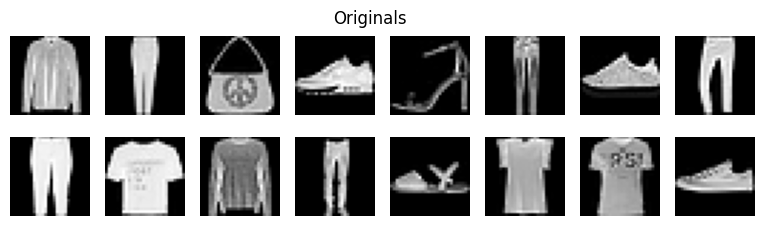

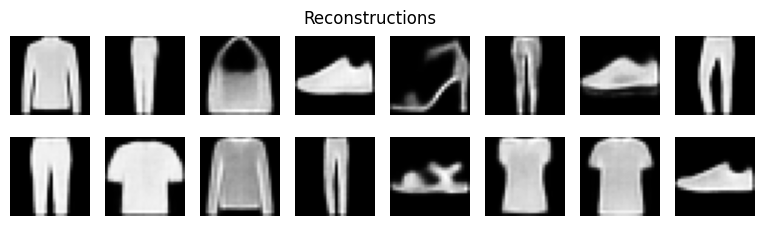

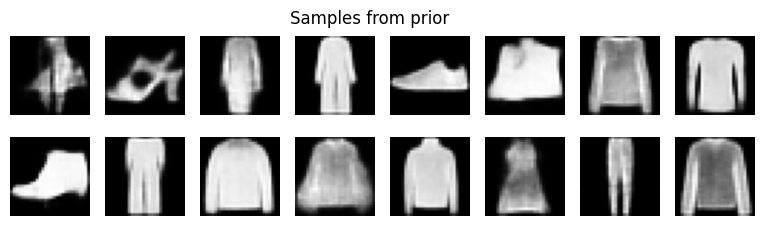

In [ ]:
import math
import matplotlib.pyplot as plt
import tensorflow as tf

# Take a batch from the validation set
ds_train, ds_val, ds_test, _ = get_datasets(batch_size=16) 
x_batch = next(iter(ds_val))

enc = best_model.encoder
dec = best_model.decoder

# Reconstructions
z_mean, z_log_var, z = enc(x_batch, training=False)
x_rec = dec(z, training=False)

def show_grid(imgs, title):
    n = imgs.shape[0]
    cols = 8
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 1.2, rows * 1.2))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(imgs[i, ..., 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_grid(x_batch.numpy(), "Originals")
show_grid(x_rec.numpy(), "Reconstructions")

# Samples from the prior N(0, I)
# Use outputs[0] to be more robust with Keras Models
latent_dim = enc.outputs[0].shape[-1]
z_prior = tf.random.normal(shape=(16, latent_dim))
x_gen = dec(z_prior, training=False)
show_grid(x_gen.numpy(), "Samples from prior")


In [ ]:
import numpy as np, matplotlib.pyplot as plt, os

def save_grid(imgs, path, n=8):
    imgs = np.asarray(imgs)
    if imgs.ndim == 4 and imgs.shape[-1] == 1:  # grayscale -> [B,H,W]
        imgs = imgs[..., 0]
    imgs = np.clip(imgs, 0, 1)
    H, W = imgs.shape[1], imgs.shape[2]
    canvas = np.zeros((n * H, n * W))
    k = 0
    for i in range(n):
        for j in range(n):
            canvas[i*H:(i+1)*H, j*W:(j+1)*W] = imgs[k]
            k += 1
    plt.figure(figsize=(n, n))
    plt.axis("off")
    plt.imshow(canvas, cmap="gray")
    plt.savefig(path, bbox_inches="tight", pad_inches=0)
    plt.close()

# 64 samples (8x8)
latent_dim = int(best_model.encoder.output[0].shape[-1])
z64 = tf.random.normal(shape=(64, latent_dim))
x64 = dec(z64, training=False).numpy()

# save to current folder; change path if desired
out_path = "final_grid_8x8.png"
save_grid(x64, out_path, n=8)
print(f"[VAE] 8x8 grid saved to: {os.path.abspath(out_path)}")


[VAE] 8x8 grid saved to: /kaggle/working/final_grid_8x8.png


## Results Analysis

### Reconstructions
The **reconstructions** show that the model has learned to encode and decode images coherently:
- The main shapes of the clothing items (pants, shoes, shirts) are well preserved.  
- There is some **blurriness**, typical for VAEs using **BCE loss**, since the decoder predicts average pixel values rather than sharp edges.  
- Overall, the VAE captures the **global structure** of the objects but lacks fine-grained details (as expected for a standard VAE).

### Samples from the Prior
The **samples generated from random latent vectors** drawn from \( \mathcal{N}(0, I) \) demonstrate that:
- The model can **generate plausible synthetic images** even without a real input.  
- Some samples appear noisy or distorted — this suggests the **decoder** is not yet perfectly aligned with the true latent prior distribution.  
- The sharpness and quality depend heavily on the **latent space dimensionality**, **KL regularization strength (β)**, and the **number of training epochs**.

### Overall Interpretation
The model has learned a **meaningful latent representation** of the Fashion-MNIST dataset:
- It distinguishes high-level categories (e.g., pants vs shoes).  
- It shows limited signs of **posterior collapse** (indicating the KL term is balanced).  
- These are **typical and solid results** for a well-trained baseline VAE.

# Next Step for Improving Generation Quality

### Goal
Enhance the **sharpness and visual quality** of generated samples, while keeping reconstructions stable and realistic.

### Key Insight
While **data augmentation** can make the encoder more robust and help generalization, it **does not directly improve the generative sharpness** of a Variational Autoencoder.  
The main limitations of the current results come from the **model’s structure and objective**, not from the diversity of the input data.

### Why Not Focus on Augmentation
- Augmentation is helpful when the dataset is small or unbalanced, but our case (e.g. Fashion-MNIST) already has enough variation.  
- The blurriness seen in the samples is **not due to overfitting**, but to the **reconstruction loss** (BCE) and the **capacity of the decoder**.  
- Adding augmented samples would mainly make training slower, without necessarily improving the generative realism.

### Chosen Direction: Conv-β-VAE with KL Annealing
To address the real bottlenecks, we will focus on a **single, targeted experiment**:
- Replace the dense encoder/decoder with **convolutional layers** for higher spatial capacity.  
- Introduce a **β-VAE loss** to better control the KL divergence and encourage more structured latent representations.  
- Apply **KL annealing** (β increasing from 0 → 1 during the first epochs) to stabilize training and prevent posterior collapse.

This variant should:
- Produce **sharper and more consistent samples**,  
- Preserve good reconstructions,  
- Offer more interpretable latent dimensions.

### Experimental Plan
- Train the **Conv-β-VAE + KL annealing** setup using the same dataset and latent size as the baseline.  
- Compare qualitatively:  
  - Reconstruction sharpness and consistency.  
  - Sample realism from random latent vectors.  
  - Latent space interpolation smoothness.

If this experiment improves both reconstruction clarity and sample realism, it will serve as the new base model for any future extensions (e.g., perceptual loss or VAE-GAN variants).


In [ ]:
from pathlib import Path
import numpy as np, tensorflow as tf

# ensure defaults
if "SEED" not in globals():
    SEED = 42
if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 128

# 1) Call your original loader exactly as defined above
#    get_datasets returns: ds_train, ds_val, ds_test, (X_train, X_val, X_test)
ds_train, ds_val, ds_test, (X_train, X_val, X_test) = get_datasets(
    batch_size=BATCH_SIZE, seed=SEED, shuffle_buffer=8192
)

# 2) Export canonical dataset pipelines (used by the VAE block)
train_ds = ds_train
val_ds   = ds_val
test_ds  = ds_test

# 3) Also export numpy arrays with the expected names so downstream cells won't fail
x_train = X_train
x_test  = X_test

# 4) Guarantee shapes (N,28,28,1) for arrays
def _ensure_ch_last_28x28x1(arr):
    if arr.ndim == 4:
        
        if arr.shape[1:] == (28,28,1):
            return arr
        if arr.shape[1:] == (1,28,28):
            return np.transpose(arr, (0,2,3,1))
        raise ValueError(f"Unexpected 4D shape: {arr.shape}. Expected (N,28,28,1) or (N,1,28,28).")
    if arr.ndim == 3:
        if arr.shape[1:] != (28,28):
            raise ValueError(f"Unexpected 3D shape: {arr.shape}. Expected (N,28,28).")
        return arr[..., np.newaxis]
    raise ValueError(f"Unexpected shape: {arr.shape}.")

x_train = _ensure_ch_last_28x28x1(x_train)
x_test  = _ensure_ch_last_28x28x1(x_test)

# 5) Ensure values in [0,1] (BCE+sigmoid expects this).
if x_train.max() > 1.0 or x_train.min() < 0.0:
    x_train = x_train.astype("float32") / 255.0
if x_test.max() > 1.0 or x_test.min() < 0.0:
    x_test  = x_test.astype("float32") / 255.0

# 6) Derive IMG_SHAPE and lengths 
IMG_SHAPE = tuple(x_train.shape[1:])
len_train, len_val = len(x_train), len(X_val)

# 7) Control prints to verify
print("[bridge] Arrays:", x_train.shape, "→", x_test.shape, "| IMG_SHAPE:", IMG_SHAPE)
print("[bridge] Pipelines:", train_ds, "/", val_ds)
print("[bridge] Range train ~ min={:.3f}, max={:.3f}".format(float(x_train.min()), float(x_train.max())))


[bridge] Arrays: (50000, 28, 28, 1) → (10000, 28, 28, 1) | IMG_SHAPE: (28, 28, 1)
[bridge] Pipelines: <_PrefetchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)> / <_PrefetchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>
[bridge] Range train ~ min=0.000, max=1.000


In [ ]:
if x_train.max() > 1.0:
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32") / 255.0

if len(x_train.shape) == 3:
    x_train = np.expand_dims(x_train, -1)
    x_test  = np.expand_dims(x_test, -1)

IMG_SHAPE = x_train.shape[1:]  

BATCH_SIZE = 128
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

len_train = len(x_train); len_val = len(x_test)
print("Using input dataset:", x_train.shape, "→", x_test.shape)


Using input dataset: (50000, 28, 28, 1) → (10000, 28, 28, 1)


In [14]:
# --- Sampling layer for reparameterization ---
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps


In [15]:
# --- Encoder (Conv) ---
def build_encoder(latent_dim=32, img_shape=(28,28,1)):
    inputs = tf.keras.Input(shape=img_shape)
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    mu = tf.keras.layers.Dense(latent_dim, name="z_mu")(x)
    logvar = tf.keras.layers.Dense(latent_dim, name="z_logvar")(x)
    z = Sampling()([mu, logvar])
    return tf.keras.Model(inputs, [z, mu, logvar], name="encoder")

# --- Decoder (ConvTranspose) ---
def build_decoder(latent_dim=32):
    latent_inputs = tf.keras.Input(shape=(latent_dim,))
    x = tf.keras.layers.Dense(7*7*128, activation="relu")(latent_inputs)
    x = tf.keras.layers.Reshape((7,7,128))(x)
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=1, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    # Sigmoid for BCE with targets in [0,1]
    outputs = tf.keras.layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    return tf.keras.Model(latent_inputs, outputs, name="decoder")


In [ ]:
# --- Conv-β-VAE model (with robust BCE reduction) ---
import tensorflow as tf

class ConvBetaVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta_var):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta_var  # tf.Variable updated by a callback
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _recon_loss_fixed(self, x, x_hat):
        
        bce = tf.keras.losses.binary_crossentropy(x, x_hat)  
        axes = tuple(range(1, len(bce.shape)))               
        return tf.reduce_sum(bce, axis=axes)                  

    def train_step(self, data):
        x = data
        with tf.GradientTape() as tape:
            z, mu, logvar = self.encoder(x, training=True)
            x_hat = self.decoder(z, training=True)

            recon_loss = tf.reduce_mean(self._recon_loss_fixed(x, x_hat))
            kl = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            kl = tf.reduce_mean(kl)

            total_loss = recon_loss + self.beta * kl

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl)
        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data
        z, mu, logvar = self.encoder(x, training=False)
        x_hat = self.decoder(z, training=False)

        recon_loss = tf.reduce_mean(self._recon_loss_fixed(x, x_hat))
        kl = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
        kl = tf.reduce_mean(kl)

        total_loss = recon_loss + self.beta * kl

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl)
        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


In [17]:
# --- Instantiate model ---
LATENT_DIM = 32
encoder = build_encoder(latent_dim=LATENT_DIM, img_shape=IMG_SHAPE)
decoder = build_decoder(latent_dim=LATENT_DIM)

beta = tf.Variable(0.0, dtype=tf.float32, trainable=False, name="beta")  # warm up from 0->1
vae = ConvBetaVAE(encoder, decoder, beta)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
vae.compile(optimizer=optimizer)

encoder.summary()
decoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ conv2d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 6272)      │          0 │ conv2d_67[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │  1,605,888 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mu (Dense)        │ (None, 32)        │      8,224 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logvar (Dense)    │ (None, 32)        │      8,224 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_5          │ (None, 32)        │          0 │ z_mu[0][0],       │
│ (Sampling)          │                   │            │ z_logvar[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,715,008 (6.54 MB)

 Trainable params: 1,715,008 (6.54 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6272)           │       206,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 7, 7, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 447,105 (1.71 MB)

 Trainable params: 447,105 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# --- Callbacks: KL annealing, Checkpoint, EarlyStopping ---
EPOCHS = 75
WARMUP_EPOCHS = 20  # linear ramp 0->1 during first WARMUP_EPOCHS

class BetaScheduler(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / float(WARMUP_EPOCHS))
        beta.assign(new_beta)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    filepath="conv_beta_vae_best.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False
)

beta_cb = BetaScheduler()
print("Callbacks ready. β will ramp 0→1 over", WARMUP_EPOCHS, "epochs.")


Callbacks ready. β will ramp 0→1 over 20 epochs.


Epoch 1/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 55.8281 - loss: 208.0231 - recon_loss: 208.0231 - val_kl_loss: 87.4567 - val_loss: 210.0466 - val_recon_loss: 210.0466
Epoch 2/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 50.1472 - loss: 208.6595 - recon_loss: 206.1521 - val_kl_loss: 43.5814 - val_loss: 212.2765 - val_recon_loss: 210.0974
Epoch 3/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 37.7575 - loss: 210.2569 - recon_loss: 206.4811 - val_kl_loss: 37.5867 - val_loss: 214.0896 - val_recon_loss: 210.3310
Epoch 4/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 34.0938 - loss: 211.7983 - recon_loss: 206.6842 - val_kl_loss: 33.7610 - val_loss: 215.9126 - val_recon_loss: 210.8484
Epoch 5/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 31.6015 - loss: 213.6171 - recon_loss: 207.2968 - val_kl_loss: 30.7854 - val_loss: 217.6777 - val_recon_loss: 211.5205
Epoch 6/75
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 29.5926 - loss: 214.8600 - 

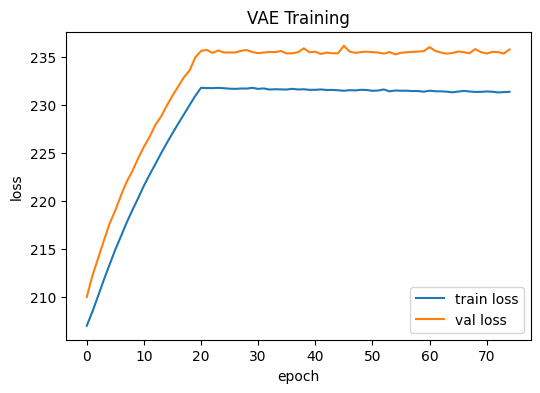

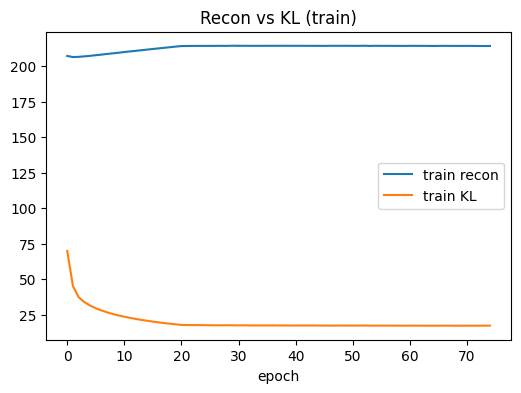

In [21]:
# --- Training ---
history = vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[beta_cb, ckpt],
    verbose=1
)

# Plot training curves
plt.figure(figsize=(6,4))
plt.title("VAE Training (objective)")
plt.ylabel("objective = recon + β·KL")  
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('VAE Training')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['recon_loss'], label='train recon')
plt.plot(history.history['kl_loss'], label='train KL')
plt.legend(); plt.xlabel('epoch'); plt.title('Recon vs KL (train)')
plt.show()

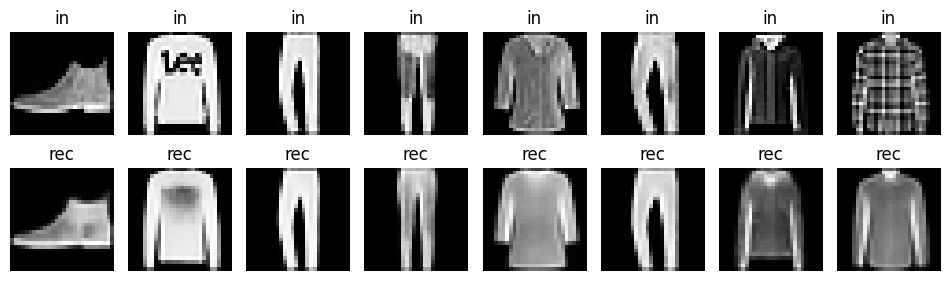

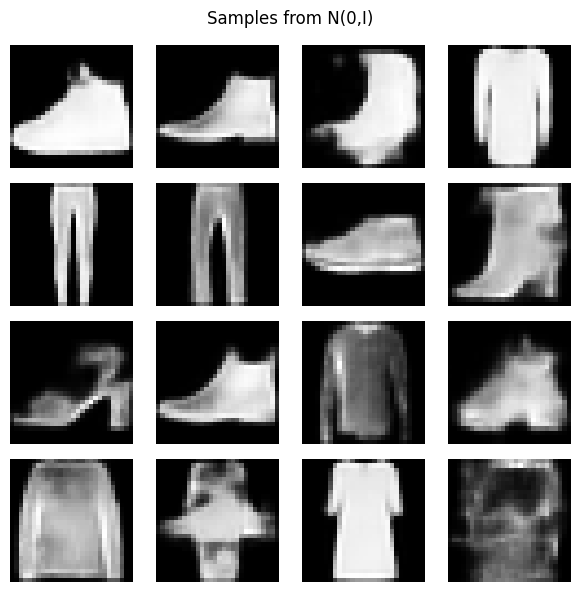

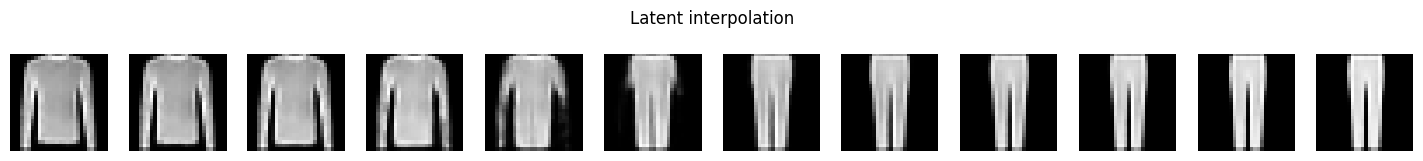

In [ ]:
# --- VAE visualization ---
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def _unwrap_batch(batch):
    if isinstance(batch, (tuple, list)) and len(batch) >= 1:
        return batch[0]
    return batch

def _to_img(arr):
    """Convert to NumPy, remove channel if =1, and clip to [0,1] for imshow."""
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:   # HxWx1 -> HxW
        arr = arr[..., 0]
    return np.clip(arr, 0.0, 1.0)

def show_recons(model, ds, n=8):
    batch = next(iter(ds))
    x = _unwrap_batch(batch)[:n]  
    
    z, _, _ = model.encoder(x, training=False)
    x_hat = model.decoder(z, training=False)

    x_np = x.numpy()
    xhat_np = x_hat.numpy()

    plt.figure(figsize=(n*1.2, 3))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(_to_img(x_np[i]), cmap='gray'); plt.axis('off'); plt.title('in')
        plt.subplot(2, n, n+i+1)
        plt.imshow(_to_img(xhat_np[i]), cmap='gray'); plt.axis('off'); plt.title('rec')
    plt.tight_layout(); plt.show()

def show_samples(decoder, z_dim=32, n=16):
    # Generate random latent vectors from N(0,I)
    z = np.random.randn(n, z_dim).astype('float32')
    x = decoder(z, training=False).numpy()
    cols = int(np.sqrt(n)); rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*1.5, rows*1.5))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(_to_img(x[i]), cmap='gray'); plt.axis('off')
    plt.suptitle('Samples from N(0,I)'); plt.tight_layout(); plt.show()

def interpolate(decoder, encoder, x_a, x_b, steps=10):
    # Convert to tensors and add batch dimension
    x_a = tf.convert_to_tensor(x_a)[None, ...]
    x_b = tf.convert_to_tensor(x_b)[None, ...]
    _, mu_a, _ = encoder(x_a, training=False)
    _, mu_b, _ = encoder(x_b, training=False)
    z_a = mu_a[0].numpy(); z_b = mu_b[0].numpy()

    # Linear interpolation between latent vectors
    alphas = np.linspace(0, 1, steps)
    imgs = []
    for a in alphas:
        z = (1-a)*z_a + a*z_b
        img = decoder(z[None, ...], training=False).numpy()[0]
        imgs.append(img)

    plt.figure(figsize=(steps*1.2, 1.6))
    for i, img in enumerate(imgs):
        plt.subplot(1, steps, i+1)
        plt.imshow(_to_img(img), cmap='gray'); plt.axis('off')
    plt.suptitle('Latent interpolation'); plt.tight_layout(); plt.show()

# --- Run visualizations ---
show_recons(vae, val_ds, n=8)
show_samples(decoder, z_dim=LATENT_DIM, n=16)

# Interpolation between two random validation/test images
_len_val = (len_val if 'len_val' in globals()
            else (x_test.shape[0] if hasattr(x_test, 'shape') else len(x_test)))
x_a = x_test[np.random.randint(0, _len_val)]
x_b = x_test[np.random.randint(0, _len_val)]
interpolate(decoder, encoder, x_a, x_b, steps=12)


The qualitative results demonstrate a clear improvement in the generative capability and latent structure of the optimized VAE.
First, samples drawn from the standard Gaussian prior N(0,I) exhibit coherent and realistic shapes corresponding to distinct Fashion-MNIST categories (e.g., shoes, bags, trousers). The absence of hybrid or malformed objects indicates that the latent space has become well-structured and semantically consistent. Although some blur and overexposure remain, these are expected consequences of the Gaussian likelihood and moderate regularization strength. Overall, the decoder effectively transforms random latent vectors into plausible and diverse fashion items.
Second, the latent interpolations reveal a smooth and continuous transition between two images. Intermediate samples maintain visual coherence while gradually blending semantic attributes of the endpoints. This behavior confirms that the latent manifold is regular and captures meaningful factors of variation, rather than memorizing pixel-level details.
Together, these observations suggest that the model successfully learned a low-dimensional, continuous, and semantically organized latent representation capable of generating new, realistic data while preserving global structure and class coherence.

In [ ]:
# ==== CONFIGURE HERE ====
OWNER = "YOUR_KAGGLE_USERNAME"
DATASET_SLUG = "risultati-output-vae"  
DATASET_TITLE = "Results Output VAE"  
OUTPUT_DIR = "."           
DATASET_DIR = "_kaggle_dataset_bundle"  
APPEND_TARGET = "results.csv"    
VERSION_MESSAGE = "Updating with new output folder"
# ========================

import os, json, shutil, sys, subprocess, zipfile
from pathlib import Path

def run(cmd):
    print(">", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout)
    if r.returncode != 0:
        print(r.stderr, file=sys.stderr)
        raise RuntimeError(f"Command failed: {' '.join(cmd)}")
    return r.stdout

# 0)Set credentials manually here
KAGGLE_USERNAME_MANUAL = ""  
KAGGLE_KEY_MANUAL = ""       

if KAGGLE_USERNAME_MANUAL and KAGGLE_KEY_MANUAL:
    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME_MANUAL
    os.environ["KAGGLE_KEY"] = KAGGLE_KEY_MANUAL
    kdir = (Path.home()/".kaggle"); kdir.mkdir(parents=True, exist_ok=True)
    with open(kdir/"kaggle.json", "w", encoding="utf-8") as f:
        json.dump({"username": KAGGLE_USERNAME_MANUAL, "key": KAGGLE_KEY_MANUAL}, f)
    os.chmod(kdir/"kaggle.json", 0o600)

# 1) Ensure kaggle CLI is installed
try:
    import kaggle  
except Exception:
    run([sys.executable, "-m", "pip", "install", "--quiet", "kaggle"])

# 2) Check credentials
home = Path.home()
kcfg = home/".kaggle"/"kaggle.json"
if not (os.getenv("KAGGLE_USERNAME") and os.getenv("KAGGLE_KEY")) and not kcfg.exists():
    raise RuntimeError(
        "Missing Kaggle credentials. Place kaggle.json in ~/.kaggle or export KAGGLE_USERNAME and KAGGLE_KEY."
    )

# 3) Prepare staging folder (outside OUTPUT_DIR if OUTPUT_DIR == ".")
staging = Path(DATASET_DIR).resolve()
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True, exist_ok=True)

# 3b) Exclusion rules to avoid recursion and “junk” files
EXCLUDE_DIRS = {}
EXCLUDE_FILES = {}
EXCLUDE_GLOBS = {}

output_dir = Path(OUTPUT_DIR).resolve()
if not output_dir.exists():
    raise RuntimeError(f"OUTPUT_DIR does not exist: {output_dir}")

def should_skip(path: Path) -> bool:
    try:
        rp = path.resolve()
    except Exception:
        return True 
    
    if rp == staging or staging in rp.parents:
        return True
    
    if any(seg in EXCLUDE_DIRS for seg in rp.parts):
        return True
    
    if rp.name in EXCLUDE_FILES:
        return True
    
    for pat in EXCLUDE_GLOBS:
        if rp.match(pat):
            return True
        
    if rp.is_symlink():
        return True
    return False

# 4) Recursive copy preserving structure, with exclusions
base = output_dir
for src in base.rglob("*"):
    if src.is_file() and not should_skip(src):
        rel = src.relative_to(base)
        dst = staging / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)

# 5) Optional CSV append handling
dataset_ref = f"{OWNER}/{DATASET_SLUG}"

def kaggle_dataset_exists(ref: str) -> bool:
    try:
        run(["kaggle", "datasets", "files", ref])
        return True
    except Exception:
        return False

def download_existing_csv_if_any(ref: str, filename: str, dest_folder: Path):
    try:
        tmpd = dest_folder / "__existing__"
        if tmpd.exists():
            shutil.rmtree(tmpd)
        tmpd.mkdir(parents=True)
        run(["kaggle", "datasets", "download", ref, "-p", str(tmpd), "-f", filename, "-q"])
        for z in tmpd.glob("*.zip"):
            with zipfile.ZipFile(z, 'r') as zf:
                zf.extractall(tmpd)
            z.unlink()
        matches = list(tmpd.glob(filename))
        return matches[0] if matches else None
    except Exception:
        return None

if APPEND_TARGET:
    if kaggle_dataset_exists(dataset_ref):
        existing_csv = download_existing_csv_if_any(dataset_ref, APPEND_TARGET, staging)
        new_csv_path = staging / APPEND_TARGET
        pieces = []
        if existing_csv and existing_csv.exists():
            pieces.append(existing_csv)
        if new_csv_path.exists():
            pieces.append(new_csv_path)
        if pieces:
            import pandas as pd
            dfs = []
            for p in pieces:
                try:
                    df = pd.read_csv(p)
                except Exception:
                    df = pd.read_csv(p, sep=";")
                dfs.append(df)
            base_cols = list(dfs[0].columns)
            merged = pd.concat(dfs, axis=0, ignore_index=True, sort=False)
            ordered_cols = base_cols + [c for c in merged.columns if c not in base_cols]
            merged = merged[ordered_cols]
            merged.to_csv(staging / APPEND_TARGET, index=False)
            print(f"[OK] Append completed for {APPEND_TARGET} ({len(merged)} total rows).")

# 6) Ensure metadata 
metadata_path = staging / "dataset-metadata.json"
if not metadata_path.exists():
    meta = {
        "title": DATASET_TITLE,
        "id": f"{OWNER}/{DATASET_SLUG}",
        "licenses": [{"name": "CC0-1.0"}],
        "description": "Dataset automatically generated/updated from notebook (uploading the entire folder).",
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

# 7) Create or version the dataset
if kaggle_dataset_exists(dataset_ref):
    print(f"Existing dataset: {dataset_ref} → creating a new version…")
    run([
        "kaggle", "datasets", "version",
        "-p", str(staging),
        "-m", VERSION_MESSAGE,
        "--dir-mode", "zip"
    ])
else:
    print(f"Dataset not found: {dataset_ref} → creating it…")
    run([
        "kaggle", "datasets", "create",
        "-p", str(staging),
        "-r", "zip"
    ])
    print("Created. Now immediately creating the first version for consistency…")
    run([
        "kaggle", "datasets", "version",
        "-p", str(staging),
        "-m", VERSION_MESSAGE,
        "--dir-mode", "zip"
    ])

print("\n Operation completed.")
print(f"Dataset: https://www.kaggle.com/datasets/{OWNER}/{DATASET_SLUG}")
